# 09 — Data Visualization: Titanic Dataset

**Objective:** Create 8 meaningful visualizations using Matplotlib and Seaborn, and explain what each chart communicates.

**Before you begin:** Run `07_Data_Cleaning.ipynb` and `08_Exploratory_Data_Analysis.ipynb`. This notebook loads `data/titanic_cleaned.csv` when available, otherwise it uses Seaborn's public Titanic dataset.

Run all cells from top to bottom. Use the actual charts and printed values to complete the interpretation prompts. Charts show association, not causation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

paths = [Path("data/titanic_cleaned.csv"), Path("../data/titanic_cleaned.csv")]
data_path = next((p for p in paths if p.exists()), None)

if data_path:
    df = pd.read_csv(data_path)
    print(f"Loaded: {data_path}")
else:
    df = sns.load_dataset("titanic")
    print("Cleaned CSV not found; using Seaborn's public Titanic dataset.")

print("Dataset shape:", df.shape)
display(df.head())

Cleaned CSV not found; using Seaborn's public Titanic dataset.
Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Visualization 1 — Passenger Survival Count
A count plot compares the number of passengers who survived with those who did not.

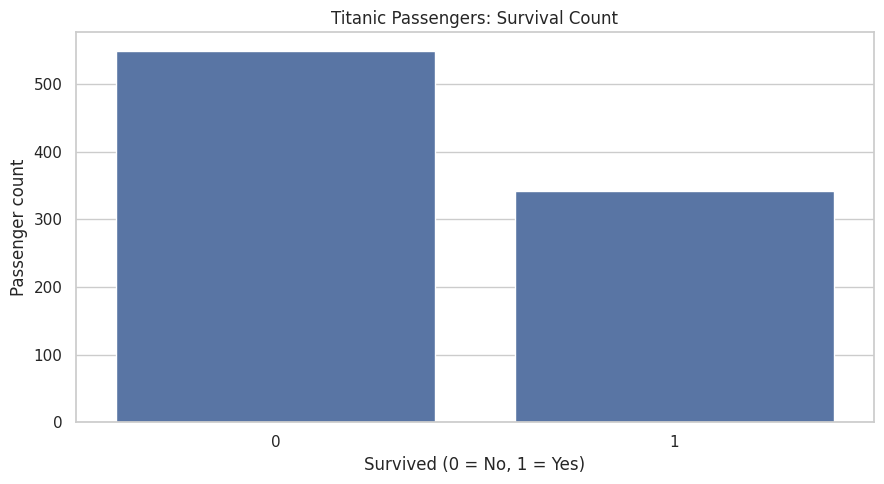

Counts:


,passenger_count
survived,
0,549
1,342


In [2]:
plt.figure()
sns.countplot(data=df, x="survived")
plt.title("Titanic Passengers: Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger count")
plt.tight_layout()
plt.show()

print("Counts:")
display(df["survived"].value_counts(dropna=False).sort_index().rename("passenger_count").to_frame())

**Interpretation:** Which outcome has the larger count? Record the counts and describe the difference.

## Visualization 2 — Survival Rate by Sex
A bar chart compares the proportion surviving in each sex category.

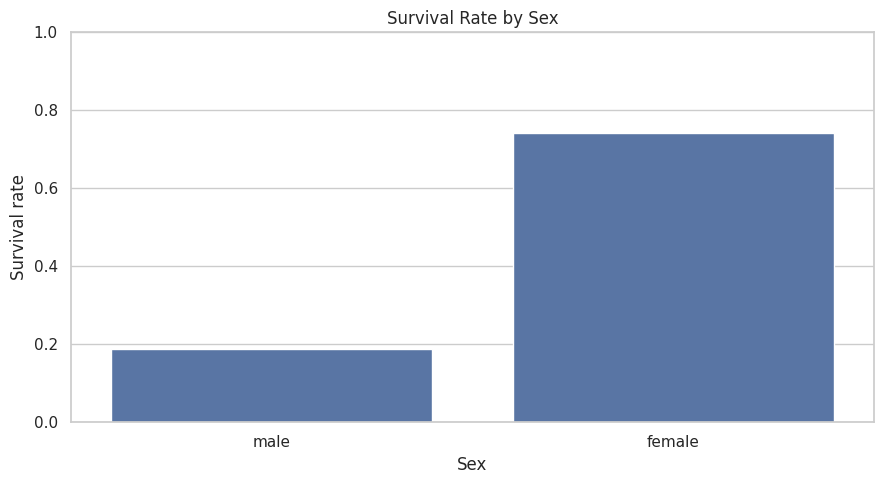

,survival_rate_percent
sex,
female,74.20
male,18.89


In [3]:
plt.figure()
sns.barplot(data=df, x="sex", y="survived", errorbar=None)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

display((df.groupby("sex", observed=False)["survived"].mean()*100).round(2).rename("survival_rate_percent").to_frame())

**Interpretation:** Compare the displayed survival percentages. Avoid making claims about why the difference occurred.

## Visualization 3 — Survival Rate by Passenger Class
This chart compares survival proportions for first, second, and third class.

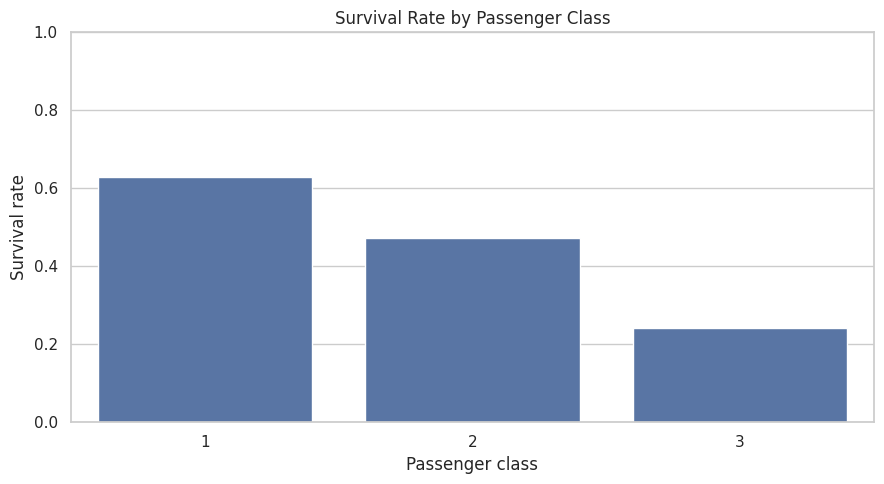

,survival_rate_percent
pclass,
1,62.96
2,47.28
3,24.24


In [4]:
plt.figure()
sns.barplot(data=df, x="pclass", y="survived", errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

display((df.groupby("pclass", observed=False)["survived"].mean()*100).round(2).rename("survival_rate_percent").to_frame())

**Interpretation:** Which class has the highest and lowest observed survival rate?

## Visualization 4 — Age Distribution
A histogram shows how passenger ages are distributed.

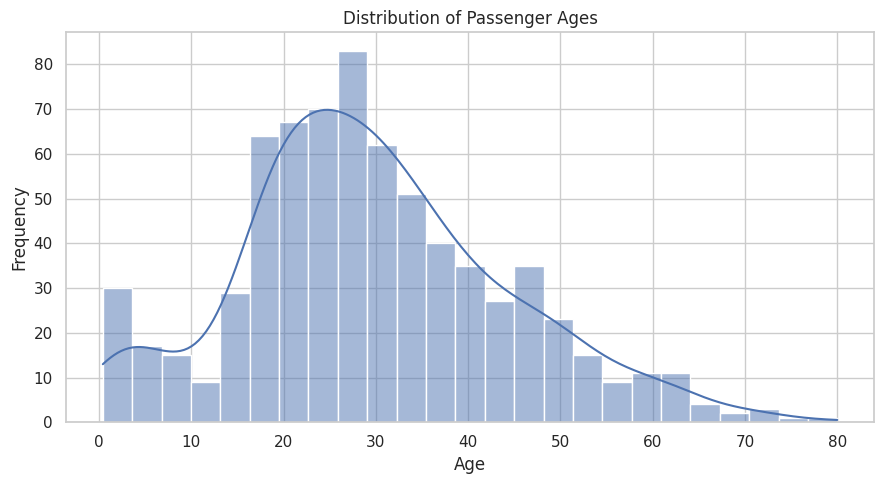

Median age: 28.0
Age range: 0.42 to 80.0


In [5]:
plt.figure()
sns.histplot(data=df, x="age", bins=25, kde=True)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Median age:", round(df["age"].median(), 2))
print("Age range:", df["age"].min(), "to", df["age"].max())

**Interpretation:** Describe where ages are concentrated and whether the distribution appears symmetric or skewed.

## Visualization 5 — Fare Distribution by Passenger Class
A box plot compares fare distributions and highlights potential extreme values.

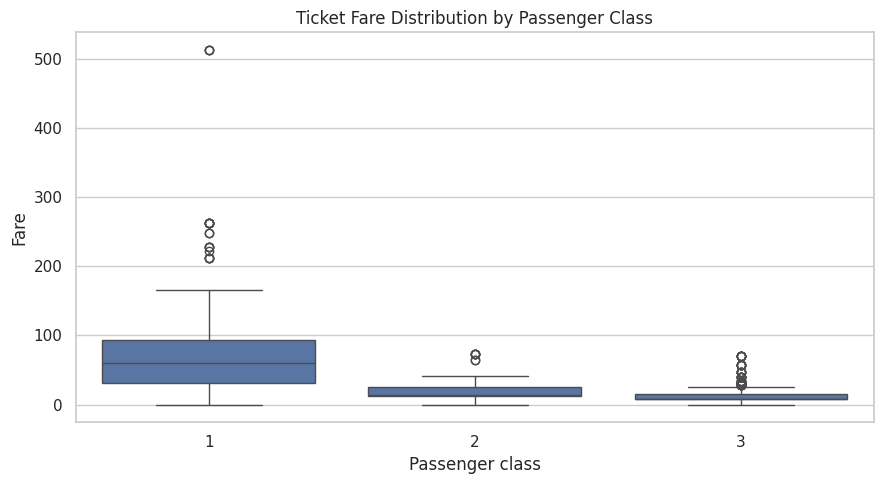

,median,mean,min,max
pclass,,,,
1,60.29,84.15,0.0,512.33
2,14.25,20.66,0.0,73.50
3,8.05,13.68,0.0,69.55


In [6]:
plt.figure()
sns.boxplot(data=df, x="pclass", y="fare")
plt.title("Ticket Fare Distribution by Passenger Class")
plt.xlabel("Passenger class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

display(df.groupby("pclass", observed=False)["fare"].agg(["median", "mean", "min", "max"]).round(2))

**Interpretation:** Compare median fares and spread across classes. Note any points or ranges that look unusually high.

## Visualization 6 — Survival Rate by Age Group
Age is grouped into readable bands before comparing survival rates.

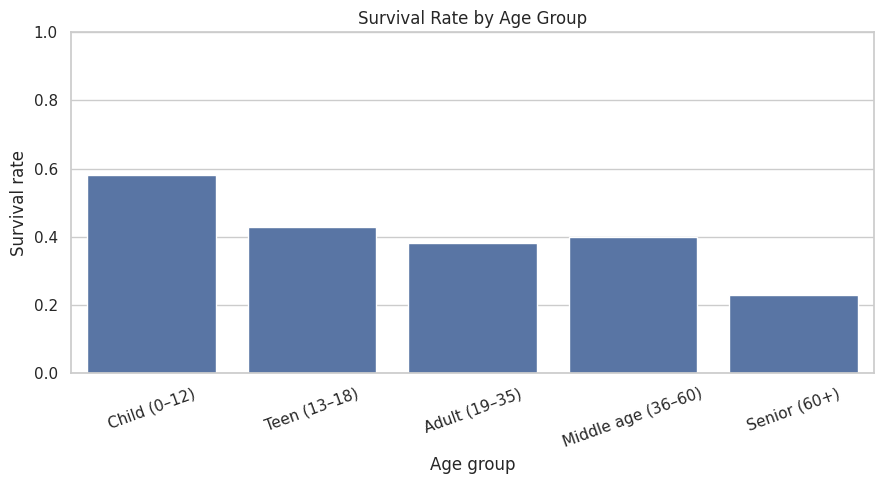

,survival_rate_percent
age_group,
Child (0–12),57.97
Teen (13–18),42.86
Adult (19–35),38.27
Middle age (36–60),40.00
Senior (60+),22.73


In [7]:
age_df = df.dropna(subset=["age", "survived"]).copy()
age_df["age_group"] = pd.cut(age_df["age"], bins=[0, 12, 18, 35, 60, 100],
                             labels=["Child (0–12)", "Teen (13–18)", "Adult (19–35)",
                                     "Middle age (36–60)", "Senior (60+)"],
                             include_lowest=True)
plt.figure()
sns.barplot(data=age_df, x="age_group", y="survived", errorbar=None)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Survival rate")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display((age_df.groupby("age_group", observed=False)["survived"].mean()*100).round(2).rename("survival_rate_percent").to_frame())

**Interpretation:** Which age group(s) show comparatively higher or lower survival? Mention that group sizes may differ.

## Visualization 7 — Survival Rate by Sex and Passenger Class
A grouped bar chart displays the combined pattern across sex and class.

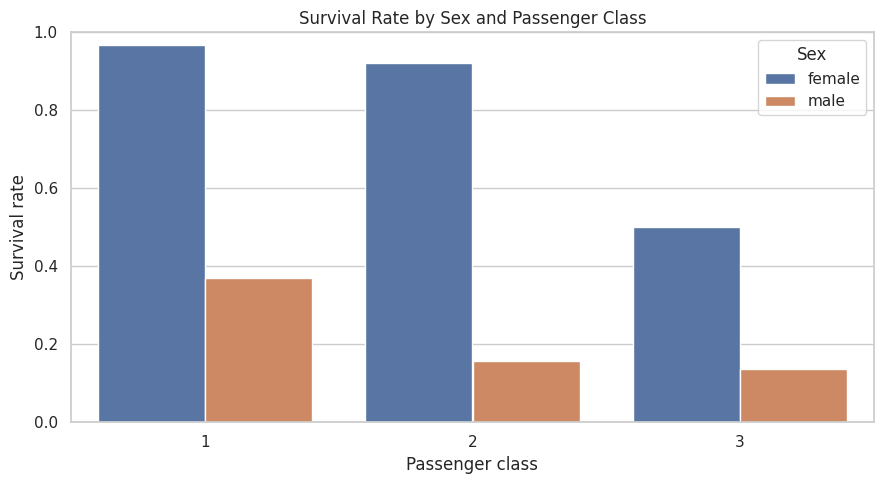

pclass,1,2,3
sex,,,
female,96.81,92.11,50.00
male,36.89,15.74,13.54


In [8]:
plt.figure()
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")
plt.ylim(0, 1)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

display((df.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean")*100).round(2))

**Interpretation:** Describe how the class pattern compares within each sex category. This is descriptive, not causal.

## Visualization 8 — Correlation Heatmap
A heatmap summarizes pairwise correlations among numeric columns. Correlation does not imply causation.

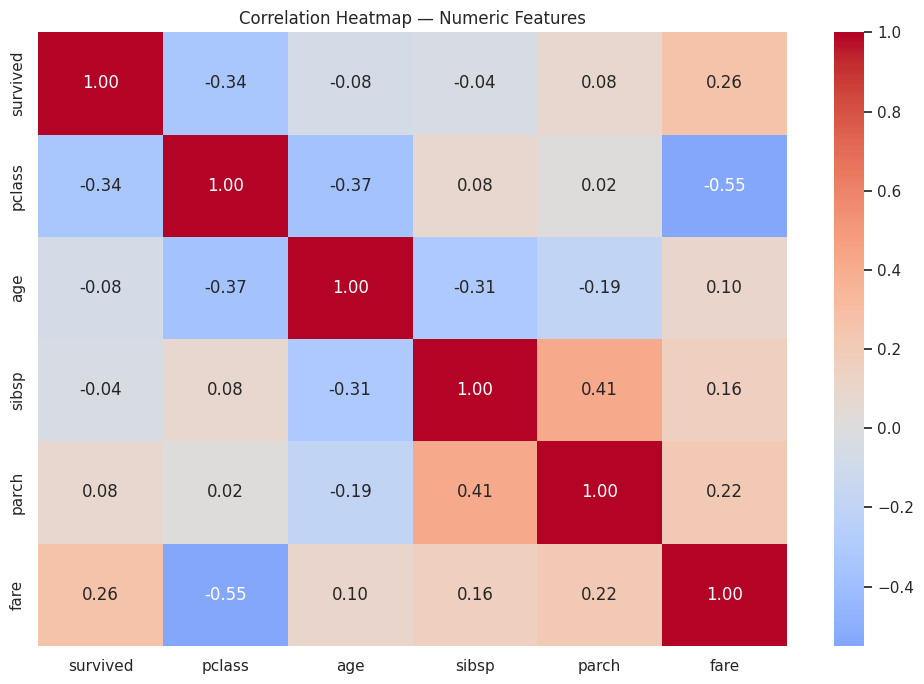

In [9]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

**Interpretation:** Identify one positive and one negative correlation (if present). Explain that correlation measures association, not cause and effect.

## Final Visualization Findings

After running the notebook, write 5–8 concise findings supported by the charts and their printed values.

1. Survival-count pattern:
2. Survival differences by sex:
3. Survival differences by passenger class:
4. Age distribution:
5. Fare distribution across classes:
6. Age-group pattern:
7. Combined sex-and-class pattern:
8. Correlation insight and limitation:

